In [ ]:
import zipfile
import os

# zip_path = "/Users/amarsawant/Downloads/ML Application/project/archive.zip"
# extract_path = "/Users/amarsawant/Downloads/ML Application/project/"

# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_path)

# print("Extraction completed!")

In [ ]:
# os.listdir(extract_path)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv("/Users/amarsawant/Downloads/ML Application/project/diabetes_binary_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [2]:
df.shape

(253680, 22)

In [3]:
df.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [5]:
df.isnull().sum()   #no null values found

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [6]:
df['Diabetes_binary'].value_counts()

Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64

In [7]:
df['Diabetes_binary'].value_counts(normalize=True)

Diabetes_binary
0.0    0.860667
1.0    0.139333
Name: proportion, dtype: float64

In [8]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


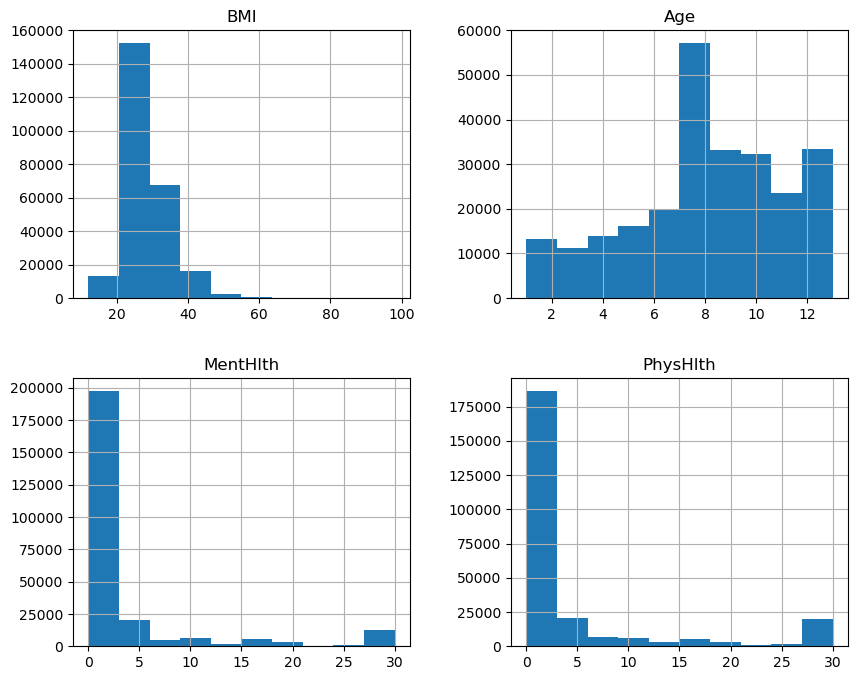

In [9]:
# checking the distribution of numerical variables
num_cols = ['BMI', 'Age', 'MentHlth', 'PhysHlth']

df[num_cols].hist(figsize=(10,8))
plt.show()

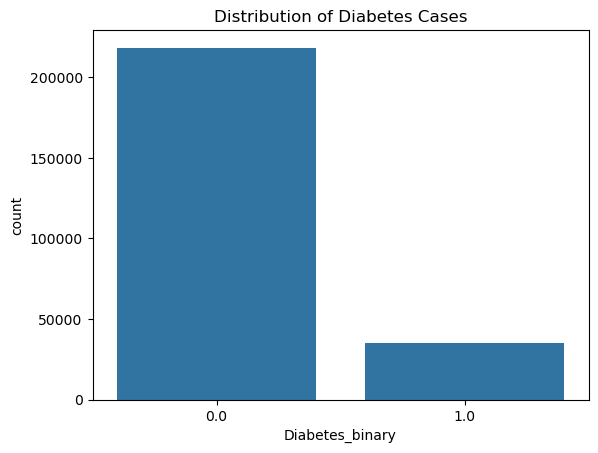

In [10]:
sns.countplot(x='Diabetes_binary', data=df)
plt.title("Distribution of Diabetes Cases")
plt.show()

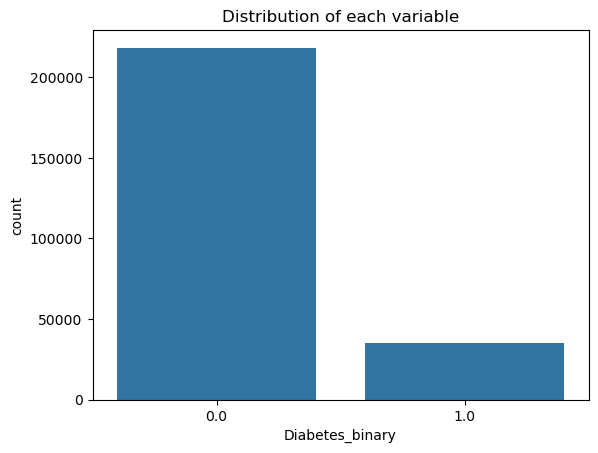

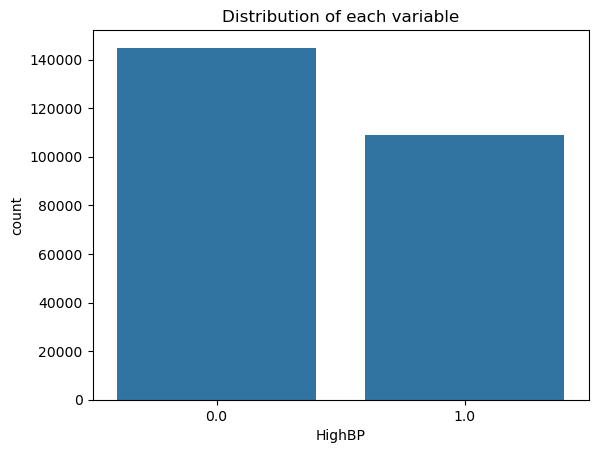

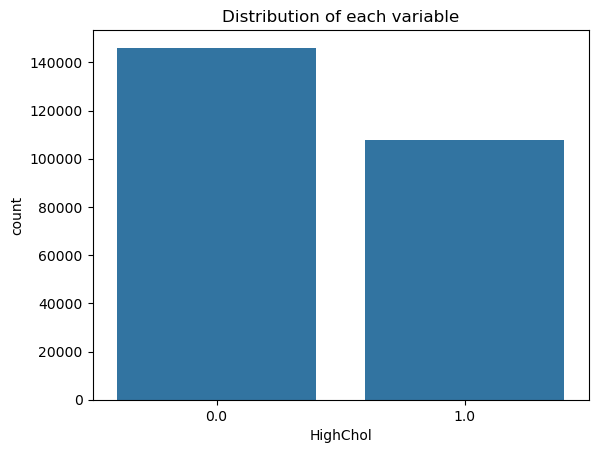

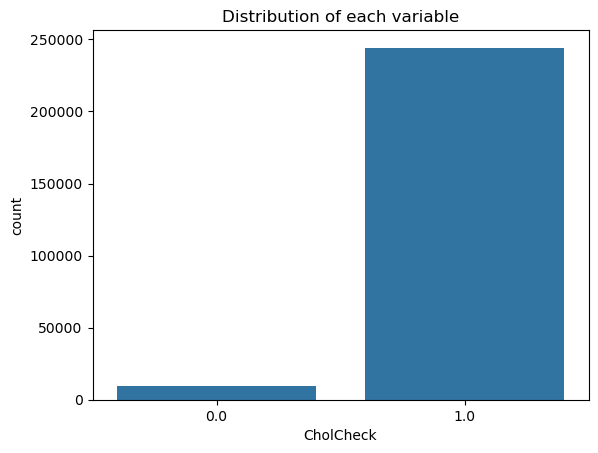

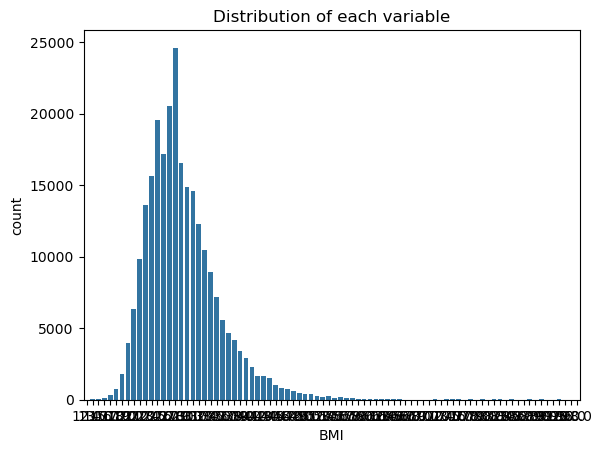

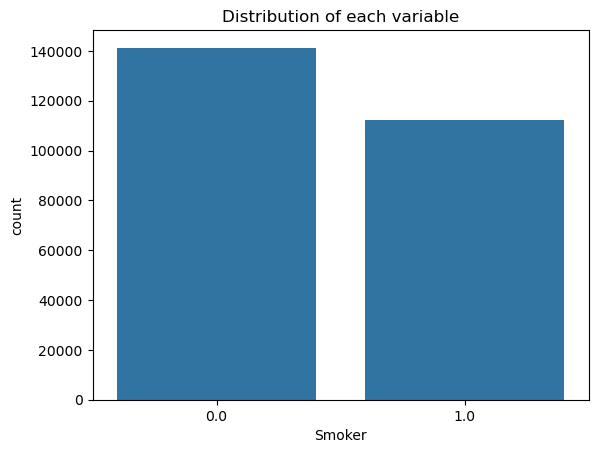

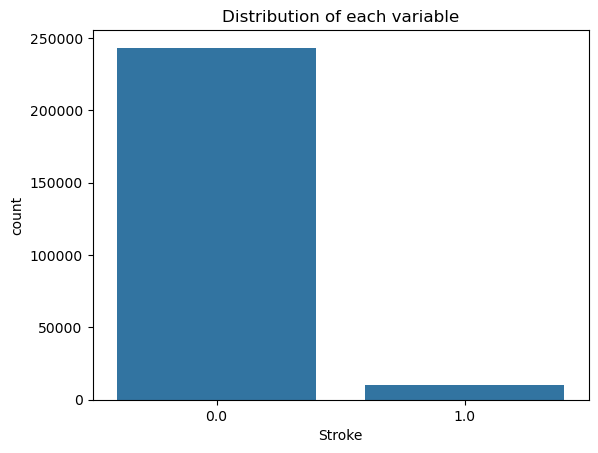

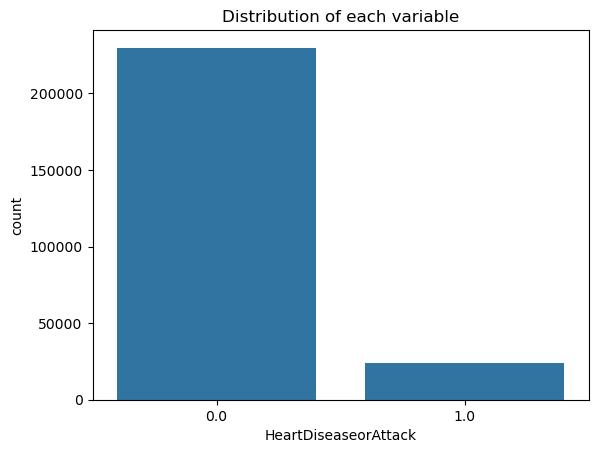

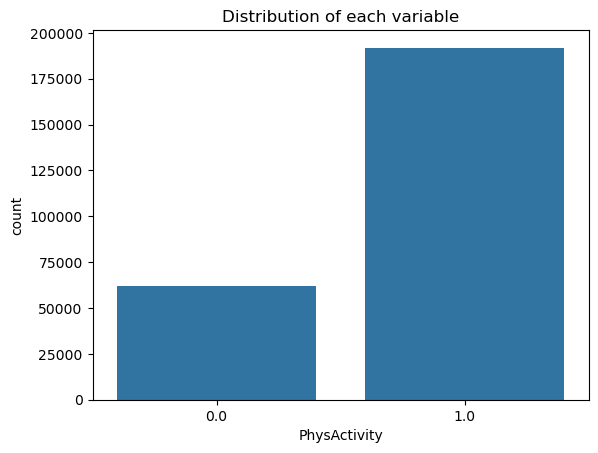

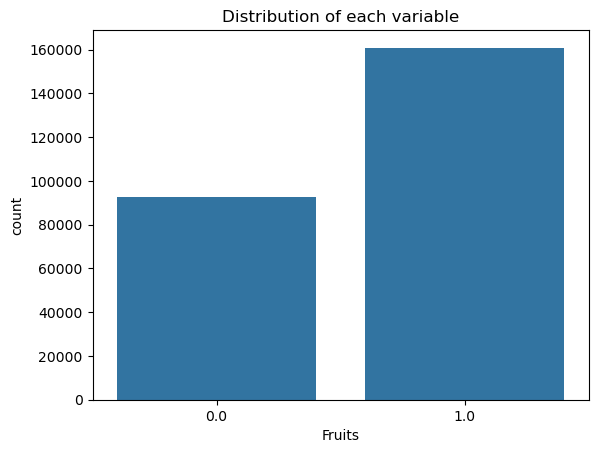

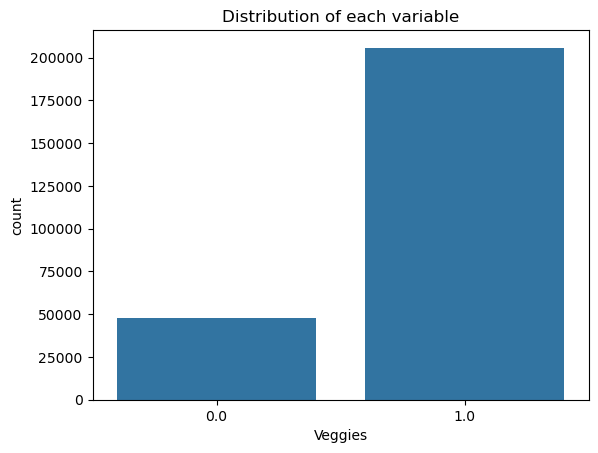

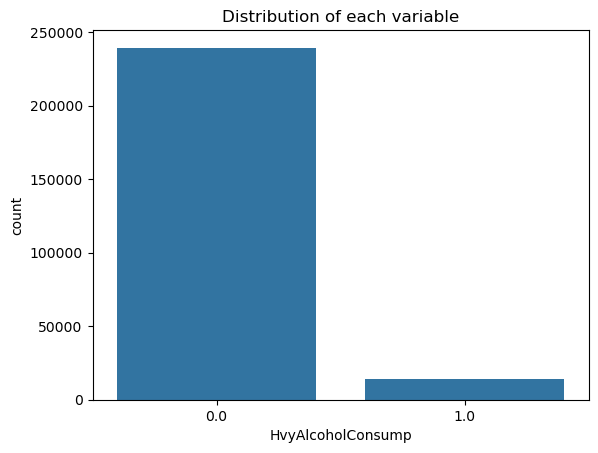

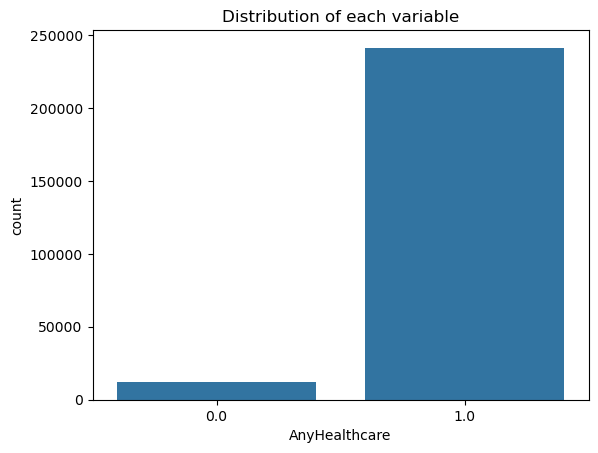

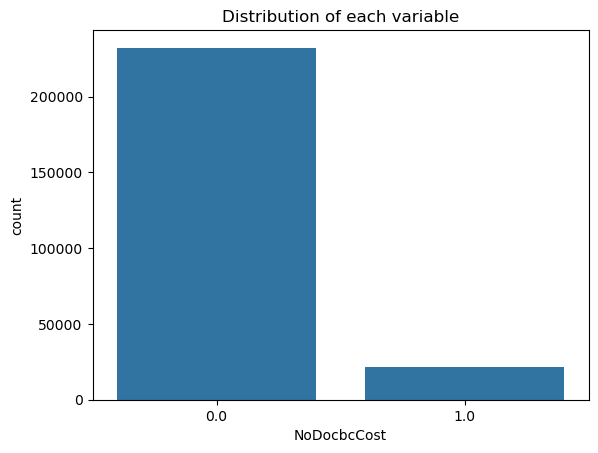

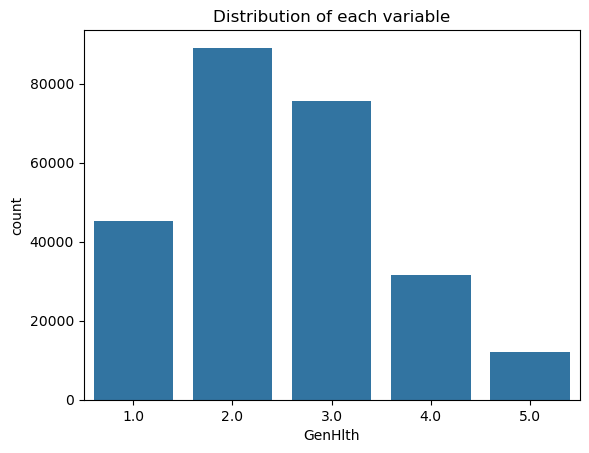

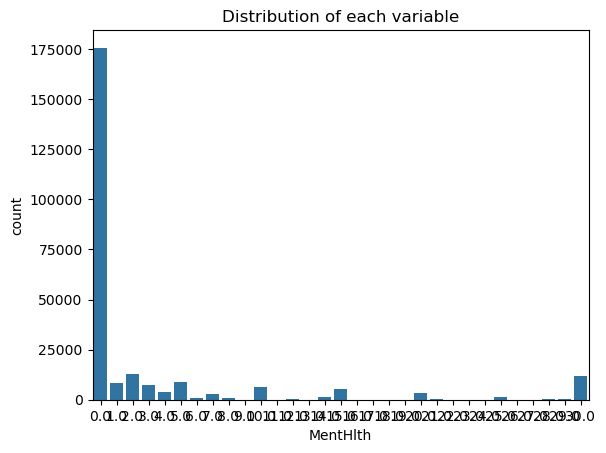

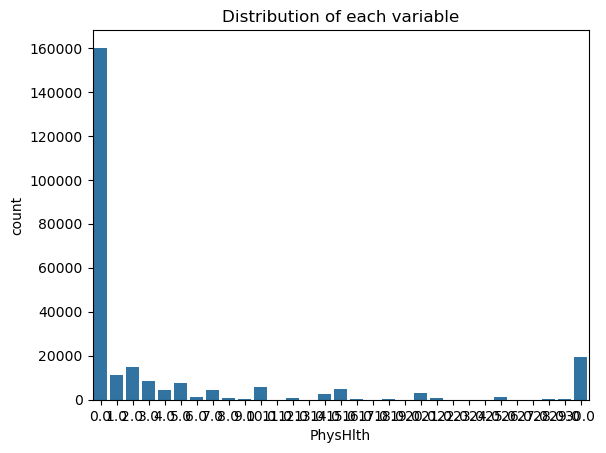

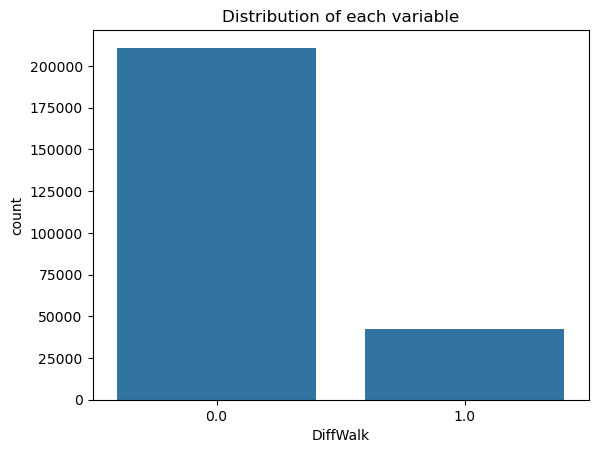

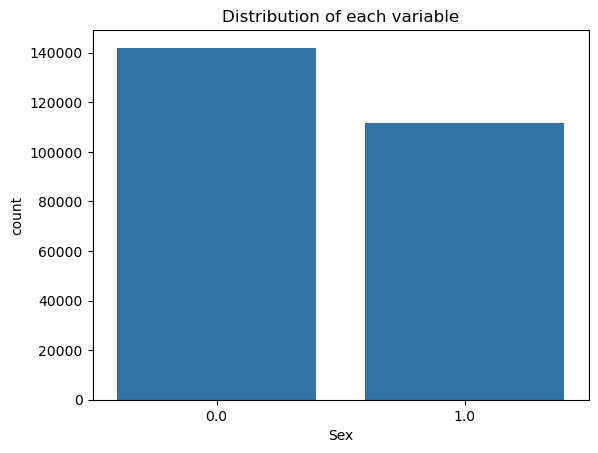

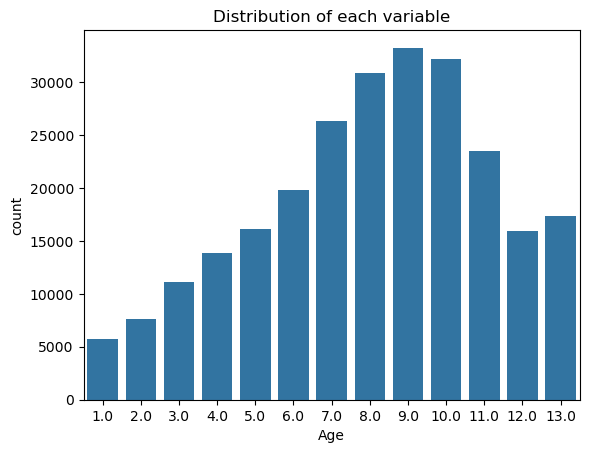

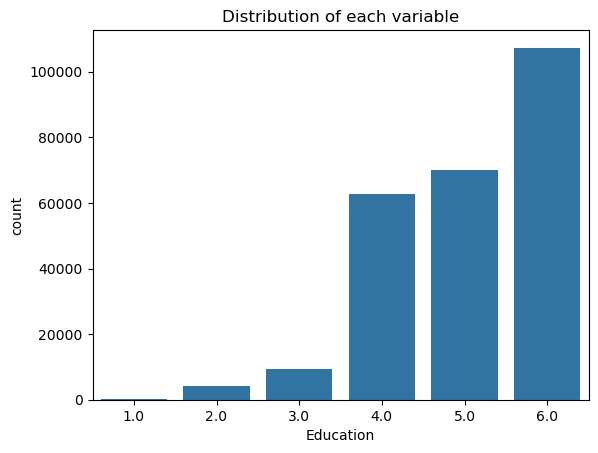

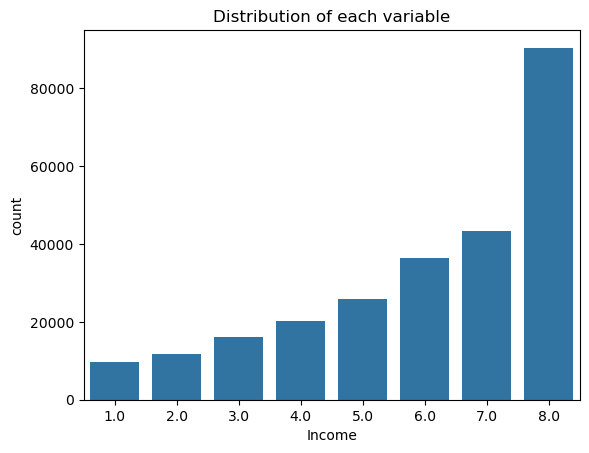

In [11]:
# checking class imabalance
col = df.columns
for c in col:

    sns.countplot(x=c, data=df)
    plt.title("Distribution of each variable")
    plt.show()

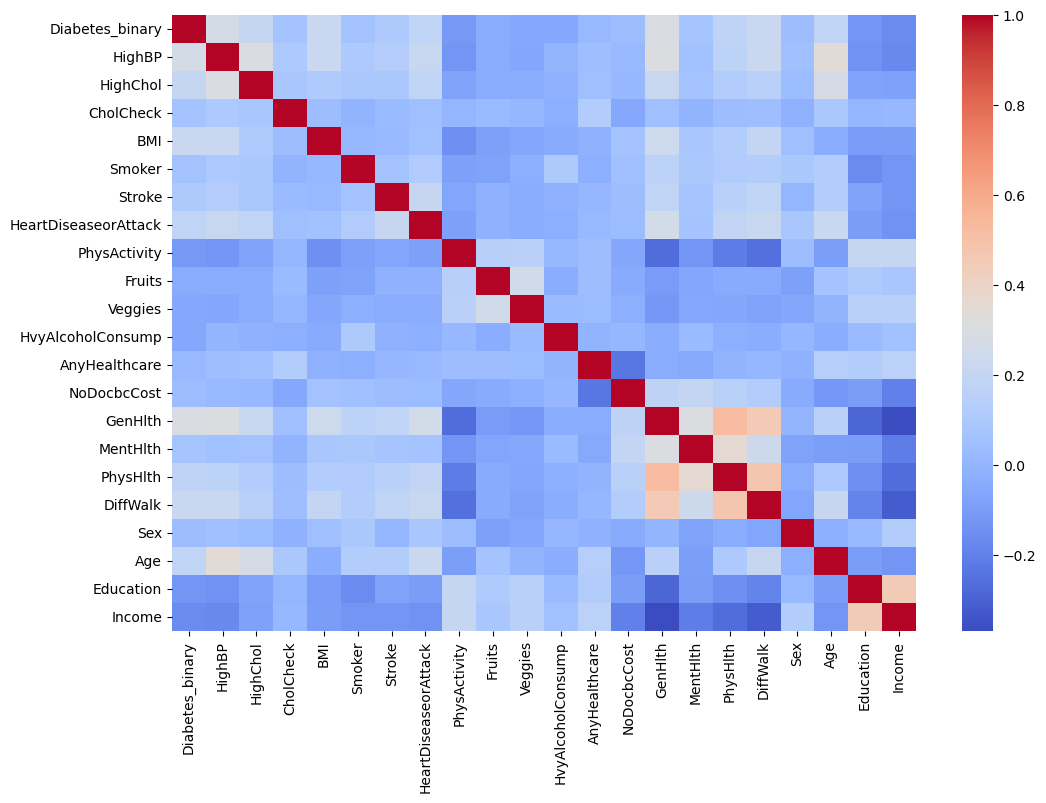

In [12]:
# Correlation Analysis
corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [13]:
correlation = df.corr()['Diabetes_binary'].sort_values(ascending=False)
correlation

Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919
Name: Diabetes_binary, dtype: float64

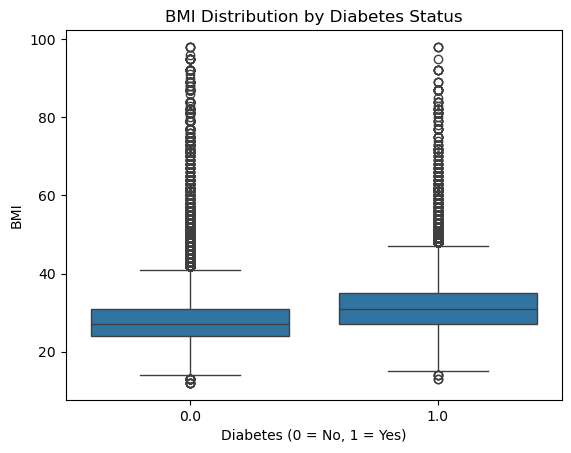

In [14]:
sns.boxplot(x='Diabetes_binary', y='BMI', data=df)
plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("BMI")

plt.show()

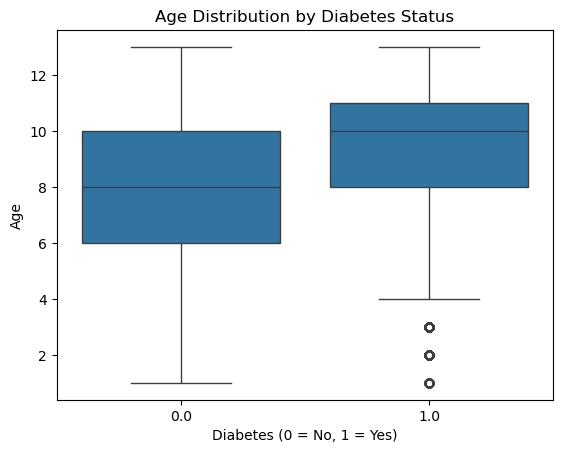

In [15]:
sns.boxplot(x='Diabetes_binary', y='Age', data=df)
plt.title("Age Distribution by Diabetes Status")
plt.xlabel("Diabetes (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

In [16]:
X = df.drop("Diabetes_binary", axis=1)
y = df["Diabetes_binary"]

In [17]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# Since our dataset size has over 250K observations, it becomes computationally expensive so we decided to use a smaller subset of train set to reduce modelling and hyperparameter tuning times.
# We created a stratified subset from the training dataset and left test set unchanged

X_train, _, y_train, _ = train_test_split(
    X_train_full,
    y_train_full,
    train_size=50000,
    stratify=y_train_full,
    random_state=42
)

print("Training subset size:", X_train.shape)
print("Test set size:", X_test.shape)

Training subset size: (50000, 21)
Test set size: (50736, 21)


In [19]:
# checking distribution of y_train_full, y_train and y_test to ensure it is similar

print('\nDistribution of y_train_full: ', y_train_full.value_counts(normalize=True))
print('\nDistribution of y_train: ', y_train.value_counts(normalize=True))
print('\nDistribution of y_test: ',y_test.value_counts(normalize=True))

# distribution of classes in subsets found consistent with dataset


Distribution of y_train_full:  Diabetes_binary
0.0    0.860311
1.0    0.139689
Name: proportion, dtype: float64

Distribution of y_train:  Diabetes_binary
0.0    0.86032
1.0    0.13968
Name: proportion, dtype: float64

Distribution of y_test:  Diabetes_binary
0.0    0.86209
1.0    0.13791
Name: proportion, dtype: float64


In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#------------------------------ MODEL-1 : Logistic Regression -----------------------

========== BASELINE LOGISTIC REGRESSION ==========

--- Training Results ---
Accuracy: 0.86272
ROC-AUC: 0.8257062331265002
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43016
         1.0       0.53      0.16      0.25      6984

    accuracy                           0.86     50000
   macro avg       0.70      0.57      0.59     50000
weighted avg       0.83      0.86      0.83     50000


--- Test Results ---
Accuracy: 0.8656378114159571
ROC-AUC: 0.8262143767473737
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43739
         1.0       0.54      0.17      0.26      6997

    accuracy                           0.87     50736
   macro avg       0.71      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736



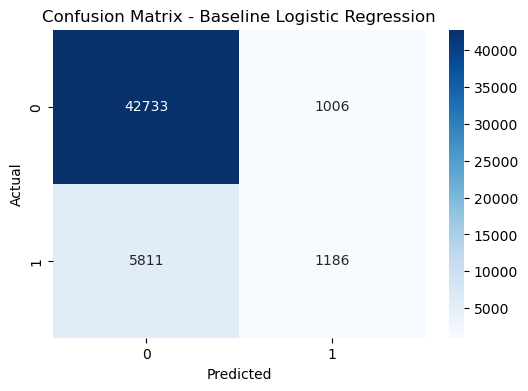

========== BALANCED LOGISTIC REGRESSION ==========

--- Training Results ---
Accuracy: 0.73496
ROC-AUC: 0.8263665437842356
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.83     43016
         1.0       0.32      0.77      0.45      6984

    accuracy                           0.73     50000
   macro avg       0.63      0.75      0.64     50000
weighted avg       0.86      0.73      0.77     50000


--- Test Results ---
Accuracy: 0.7333845789971618
ROC-AUC: 0.8265838361031899
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43739
         1.0       0.31      0.77      0.44      6997

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736



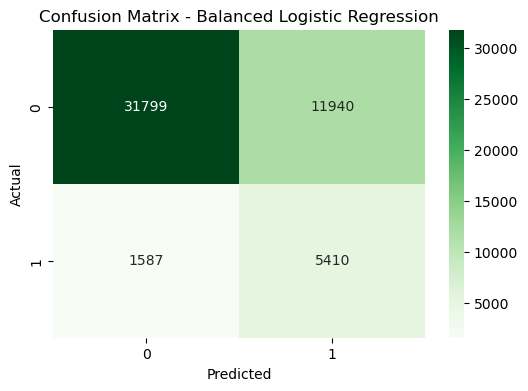

========== TUNED LOGISTIC REGRESSION ==========
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV ROC-AUC: 0.8253969663872885

--- Training Results ---
Accuracy: 0.735
ROC-AUC: 0.8263700621479507
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.83     43016
         1.0       0.32      0.77      0.45      6984

    accuracy                           0.73     50000
   macro avg       0.63      0.75      0.64     50000
weighted avg       0.86      0.73      0.77     50000


--- Test Results ---
Accuracy: 0.7333845789971618
ROC-AUC: 0.8265858260275526
              precision    recall  f1-score   support

         0.0       0.95      0.73      0.82     43739
         1.0       0.31      0.77      0.44      6997

    accuracy                           0.73     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.73      0.77     50736



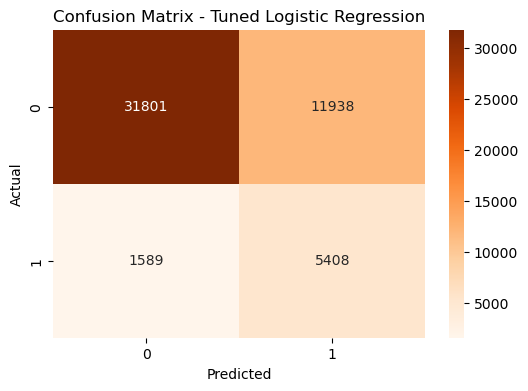

In [21]:
# ============================================================
# LOGISTIC REGRESSION - BASELINE, BALANCED, AND TUNED
# Shows BOTH training and test results
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. BASELINE LOGISTIC REGRESSION
# ------------------------------------------------------------
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = model_lr.predict(X_train_scaled)
y_test_pred_lr = model_lr.predict(X_test_scaled)

# Probabilities
y_train_prob_lr = model_lr.predict_proba(X_train_scaled)[:, 1]
y_test_prob_lr = model_lr.predict_proba(X_test_scaled)[:, 1]

print("========== BASELINE LOGISTIC REGRESSION ==========")

print("\n--- Training Results ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_lr))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_lr))
print(classification_report(y_train, y_train_pred_lr))

print("\n--- Test Results ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_lr))
print(classification_report(y_test, y_test_pred_lr))

# Confusion Matrix - Test
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.show()


# ------------------------------------------------------------
# 2. BALANCED LOGISTIC REGRESSION
# ------------------------------------------------------------
model_balanced_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced_lr.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_bal = model_balanced_lr.predict(X_train_scaled)
y_test_pred_bal = model_balanced_lr.predict(X_test_scaled)

# Probabilities
y_train_prob_bal = model_balanced_lr.predict_proba(X_train_scaled)[:, 1]
y_test_prob_bal = model_balanced_lr.predict_proba(X_test_scaled)[:, 1]

print("========== BALANCED LOGISTIC REGRESSION ==========")

print("\n--- Training Results ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_bal))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_bal))
print(classification_report(y_train, y_train_pred_bal))

print("\n--- Test Results ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_bal))
print(classification_report(y_test, y_test_pred_bal))

# Confusion Matrix - Test
cm_bal = confusion_matrix(y_test, y_test_pred_bal)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_bal, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced Logistic Regression")
plt.show()


# ------------------------------------------------------------
# 3. HYPERPARAMETER TUNING FOR LOGISTIC REGRESSION
# ------------------------------------------------------------
param_grid = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_

print("========== TUNED LOGISTIC REGRESSION ==========")
print("Best Parameters:", grid_lr.best_params_)
print("Best CV ROC-AUC:", grid_lr.best_score_)

# Predictions
y_train_pred_tuned = best_lr.predict(X_train_scaled)
y_test_pred_tuned = best_lr.predict(X_test_scaled)

# Probabilities
y_train_prob_tuned = best_lr.predict_proba(X_train_scaled)[:, 1]
y_test_prob_tuned = best_lr.predict_proba(X_test_scaled)[:, 1]

print("\n--- Training Results ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_tuned))
print(classification_report(y_train, y_train_pred_tuned))

print("\n--- Test Results ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_tuned))
print(classification_report(y_test, y_test_pred_tuned))

# Confusion Matrix - Test
cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Oranges')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned Logistic Regression")
plt.show()

In [ ]:
#--------------------------- MODEL-2: KNN ---------------------------------------

              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91     43739
         1.0       0.39      0.20      0.27      6997

    accuracy                           0.85     50736
   macro avg       0.64      0.58      0.59     50736
weighted avg       0.81      0.85      0.82     50736


Baseline KNN Model Results:

Training Performance:
              precision    recall  f1-score   support

         0.0       0.90      0.97      0.94     43016
         1.0       0.68      0.35      0.46      6984

    accuracy                           0.89     50000
   macro avg       0.79      0.66      0.70     50000
weighted avg       0.87      0.89      0.87     50000


Test Performance:
              precision    recall  f1-score   support

         0.0       0.88      0.95      0.91     43739
         1.0       0.39      0.20      0.27      6997

    accuracy                           0.85     50736
   macro avg       0.64      0.58      0.59     50736
wei

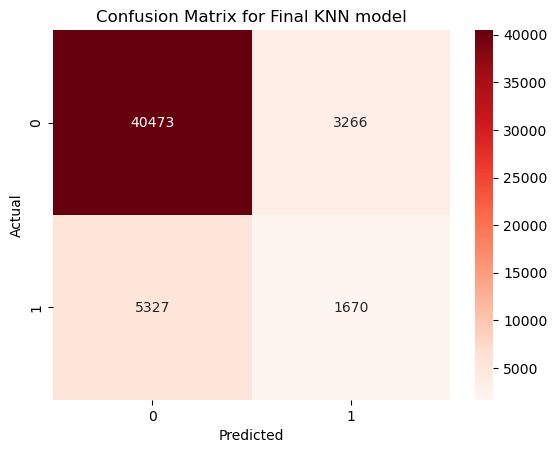

In [23]:
# ============================================================
# KNN MODEL - BASELINE + HYPERPARAMETER TUNING
# Shows BOTH training and test results
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Baseline kNN Model
# ------------------------------------------------------------
knn_baseline = KNeighborsClassifier()
knn_baseline.fit(X_train_scaled, y_train)

# ------------------------------------------------------------
# Baseline Predictions
# ------------------------------------------------------------
y_test_pred_base = knn_baseline.predict(X_test_scaled)
y_train_pred_base = knn_baseline.predict(X_train_scaled)

print(classification_report(y_test, y_test_pred_base))

print("\nBaseline KNN Model Results:")
print("\nTraining Performance:")
print(classification_report(y_train, y_train_pred_base))

print("\nTest Performance:")
print(classification_report(y_test, y_test_pred_base))

# ------------------------------------------------------------
# 2. Hyperparameter Tuning (GridSearchCV)
# ------------------------------------------------------------
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

# ------------------------------------------------------------
# 3. Final Tuned kNN Model
# ------------------------------------------------------------
knn_final = grid.best_estimator_

# ------------------------------------------------------------
# Final Model Predictions
# ------------------------------------------------------------
y_train_pred = knn_final.predict(X_train_scaled)
y_test_pred = knn_final.predict(X_test_scaled)
y_test_prob = knn_final.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 4. Model Evaluation
# ------------------------------------------------------------
print("\nFinal KNN Model Results:")

print("\nTraining Performance:")
print(classification_report(y_train, y_train_pred))

print("\nTest Performance:")
print(classification_report(y_test, y_test_pred))

print("\nROC-AUC (Test):", roc_auc_score(y_test, y_test_prob))

# ------------------------------------------------------------
# Confusion Matrix - Test
# ------------------------------------------------------------
cm_knn = confusion_matrix(y_test, y_test_pred)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for Final KNN model")
plt.show()

In [ ]:
#--------------------------- MODEL-3: Decision Tree ---------------------------------------

========== BASELINE DECISION TREE ==========

--- Training Results ---
Accuracy: 0.9977
ROC-AUC: 0.9999763267712954
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     43016
         1.0       1.00      0.98      0.99      6984

    accuracy                           1.00     50000
   macro avg       1.00      0.99      1.00     50000
weighted avg       1.00      1.00      1.00     50000


--- Test Results ---
Accuracy: 0.7939333017975402
ROC-AUC: 0.5995962780023407
              precision    recall  f1-score   support

         0.0       0.89      0.87      0.88     43739
         1.0       0.29      0.33      0.31      6997

    accuracy                           0.79     50736
   macro avg       0.59      0.60      0.59     50736
weighted avg       0.81      0.79      0.80     50736



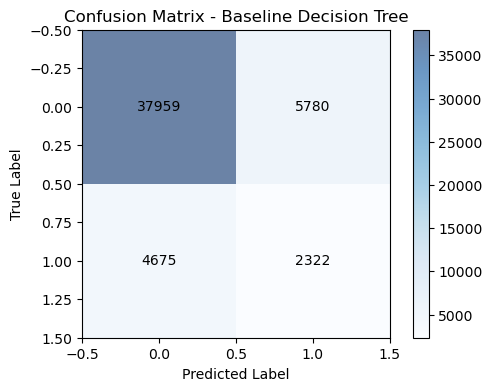

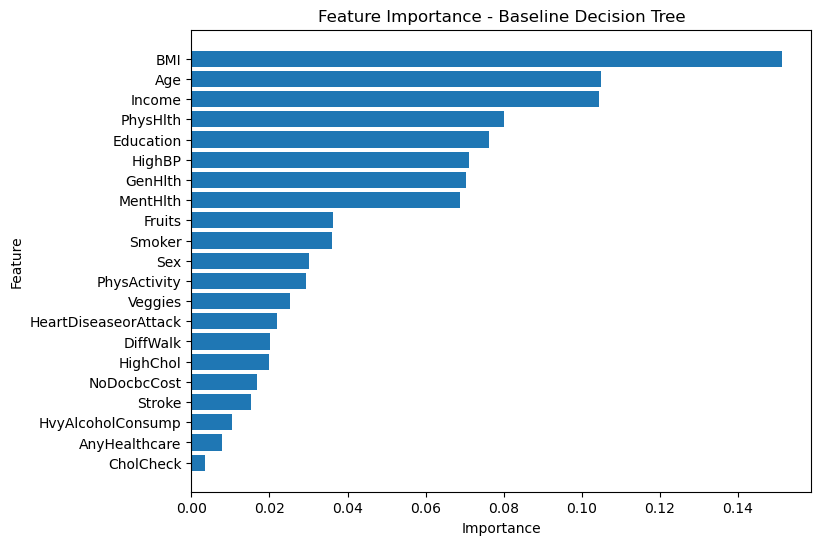

========== TUNED DECISION TREE ==========
Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best CV ROC-AUC: 0.8043038292326947

--- Training Results ---
Accuracy: 0.68332
ROC-AUC: 0.8118512347013422
              precision    recall  f1-score   support

         0.0       0.96      0.66      0.78     43016
         1.0       0.28      0.81      0.42      6984

    accuracy                           0.68     50000
   macro avg       0.62      0.74      0.60     50000
weighted avg       0.86      0.68      0.73     50000


--- Test Results ---
Accuracy: 0.6809760327972249
ROC-AUC: 0.8087165274422676
              precision    recall  f1-score   support

         0.0       0.96      0.66      0.78     43739
         1.0       0.28      0.81      0.41      6997

    accuracy                           0.68     50736
   macro avg       0.62      0.73      0.60     50736
weighted avg       0.86      0.68      0.73     50736



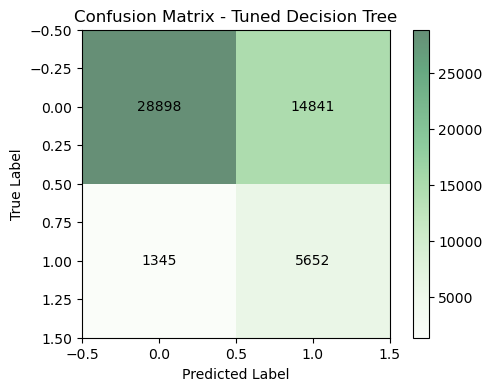

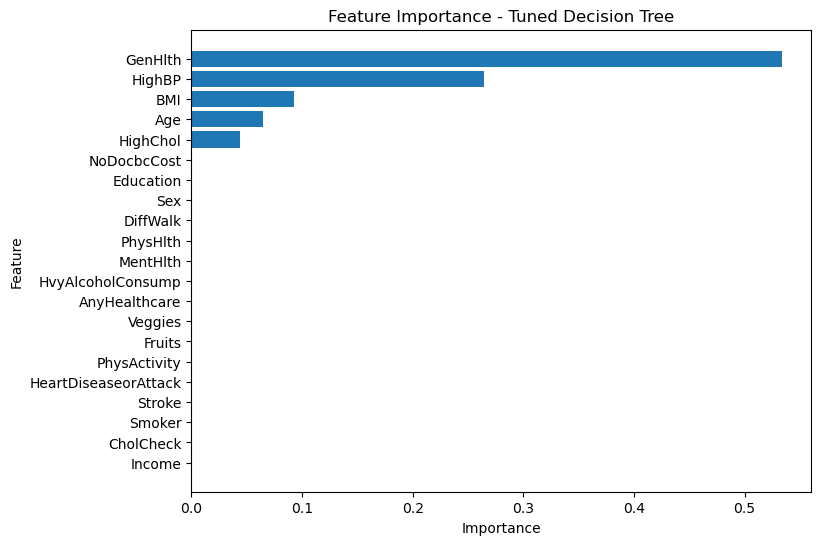

In [24]:
# ============================================================
# DECISION TREE - BASELINE + HYPERPARAMETER TUNING
# Shows BOTH training and test results
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# ------------------------------------------------------------
# 1. BASELINE DECISION TREE
# ------------------------------------------------------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Training predictions
y_train_pred_dt = dt_model.predict(X_train)
y_train_prob_dt = dt_model.predict_proba(X_train)[:, 1]

# Test predictions
y_test_pred_dt = dt_model.predict(X_test)
y_test_prob_dt = dt_model.predict_proba(X_test)[:, 1]

print("========== BASELINE DECISION TREE ==========")

print("\n--- Training Results ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_dt))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_dt))
print(classification_report(y_train, y_train_pred_dt))

print("\n--- Test Results ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_dt))
print(classification_report(y_test, y_test_pred_dt))

# Confusion Matrix - Test
cm_dt = confusion_matrix(y_test, y_test_pred_dt)
plt.figure(figsize=(6, 4))
plt.imshow(cm_dt, cmap='Blues', alpha=0.6)
plt.title("Confusion Matrix - Baseline Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(cm_dt)):
    for j in range(len(cm_dt[0])):
        plt.text(j, i, cm_dt[i][j], ha='center', va='center')

plt.colorbar()
plt.show()

# Feature Importance - Baseline
importances = dt_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.title("Feature Importance - Baseline Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()


# ------------------------------------------------------------
# 2. HYPERPARAMETER TUNING WITH GRIDSEARCHCV
# ------------------------------------------------------------
param_grid = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'class_weight': [None, 'balanced']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

print("========== TUNED DECISION TREE ==========")
print("Best Parameters:", grid_dt.best_params_)
print("Best CV ROC-AUC:", grid_dt.best_score_)


# ------------------------------------------------------------
# 3. EVALUATE TUNED DECISION TREE
# ------------------------------------------------------------
# Training predictions
y_train_pred_best_dt = best_dt.predict(X_train)
y_train_prob_best_dt = best_dt.predict_proba(X_train)[:, 1]

# Test predictions
y_test_pred_best_dt = best_dt.predict(X_test)
y_test_prob_best_dt = best_dt.predict_proba(X_test)[:, 1]

print("\n--- Training Results ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_best_dt))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_best_dt))
print(classification_report(y_train, y_train_pred_best_dt))

print("\n--- Test Results ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_best_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_best_dt))
print(classification_report(y_test, y_test_pred_best_dt))

# Confusion Matrix - Test
cm_best_dt = confusion_matrix(y_test, y_test_pred_best_dt)
plt.figure(figsize=(6, 4))
plt.imshow(cm_best_dt, cmap='Greens', alpha=0.6)
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(cm_best_dt)):
    for j in range(len(cm_best_dt[0])):
        plt.text(j, i, cm_best_dt[i][j], ha='center', va='center')

plt.colorbar()
plt.show()

# Feature Importance - Tuned
best_importances = best_dt.feature_importances_

feature_importance_best_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(feature_importance_best_df["Feature"], feature_importance_best_df["Importance"])
plt.title("Feature Importance - Tuned Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#-------------------------MODEL-4: SVM --------------------------

========== BASELINE SVM ==========

--- Training Results ---
Accuracy: 0.7188
ROC-AUC: 0.8260046349731931
              precision    recall  f1-score   support

         0.0       0.95      0.71      0.81     43016
         1.0       0.30      0.79      0.44      6984

    accuracy                           0.72     50000
   macro avg       0.63      0.75      0.63     50000
weighted avg       0.86      0.72      0.76     50000


--- Test Results ---
Accuracy: 0.7172619047619048
ROC-AUC: 0.8262202877049634
              precision    recall  f1-score   support

         0.0       0.96      0.70      0.81     43739
         1.0       0.30      0.80      0.44      6997

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.62     50736
weighted avg       0.87      0.72      0.76     50736



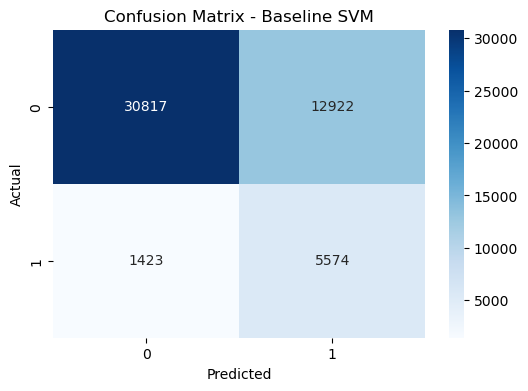

========== TUNED SVM ==========
Best Parameters: {'C': 1, 'kernel': 'linear'}
Best CV ROC-AUC: 0.8248695638946941

--- Training Results ---
Accuracy: 0.7188
ROC-AUC: 0.8260046349731931
              precision    recall  f1-score   support

         0.0       0.95      0.71      0.81     43016
         1.0       0.30      0.79      0.44      6984

    accuracy                           0.72     50000
   macro avg       0.63      0.75      0.63     50000
weighted avg       0.86      0.72      0.76     50000


--- Test Results ---
Accuracy: 0.7172619047619048
ROC-AUC: 0.8262202877049634
              precision    recall  f1-score   support

         0.0       0.96      0.70      0.81     43739
         1.0       0.30      0.80      0.44      6997

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.62     50736
weighted avg       0.87      0.72      0.76     50736



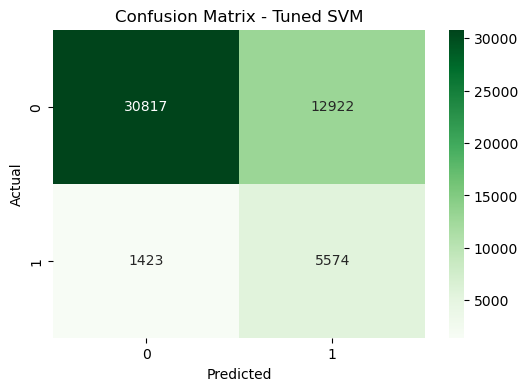

In [25]:
# ============================================================
# SVM - BASELINE + HYPERPARAMETER TUNING
# Shows BOTH training and test results
# ============================================================

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. BASELINE SVM
# ------------------------------------------------------------
svm_model = SVC(
    kernel='linear',
    C=1,
    class_weight='balanced',
    probability=True,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

# Training predictions
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_train_prob_svm = svm_model.predict_proba(X_train_scaled)[:, 1]

# Test predictions
y_test_pred_svm = svm_model.predict(X_test_scaled)
y_test_prob_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

print("========== BASELINE SVM ==========")

print("\n--- Training Results ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_svm))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_svm))
print(classification_report(y_train, y_train_pred_svm))

print("\n--- Test Results ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_svm))
print(classification_report(y_test, y_test_pred_svm))

# Confusion Matrix - Test
cm_svm = confusion_matrix(y_test, y_test_pred_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline SVM")
plt.show()


# ------------------------------------------------------------
# 2. HYPERPARAMETER TUNING WITH GRIDSEARCHCV
# ------------------------------------------------------------
param_grid = {
    'C': [0.1, 1],
    'kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(
    estimator=SVC(
        probability=True,
        class_weight='balanced',
        random_state=42
    ),
    param_grid=param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=1   # keep 1 to avoid multiprocessing/resource errors
)

grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_

print("========== TUNED SVM ==========")
print("Best Parameters:", grid_svm.best_params_)
print("Best CV ROC-AUC:", grid_svm.best_score_)


# ------------------------------------------------------------
# 3. EVALUATE TUNED SVM
# ------------------------------------------------------------
# Training predictions
y_train_pred_best_svm = best_svm.predict(X_train_scaled)
y_train_prob_best_svm = best_svm.predict_proba(X_train_scaled)[:, 1]

# Test predictions
y_test_pred_best_svm = best_svm.predict(X_test_scaled)
y_test_prob_best_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

print("\n--- Training Results ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_best_svm))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_best_svm))
print(classification_report(y_train, y_train_pred_best_svm))

print("\n--- Test Results ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_best_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_best_svm))
print(classification_report(y_test, y_test_pred_best_svm))

# Confusion Matrix - Test
cm_best_svm = confusion_matrix(y_test, y_test_pred_best_svm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_best_svm, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned SVM")
plt.show()

========== ENSEMBLE MODEL ==========

--- Training Results ---
Accuracy: 0.8673
ROC-AUC: 0.889711719989749
              precision    recall  f1-score   support

         0.0       0.93      0.91      0.92     43016
         1.0       0.52      0.59      0.56      6984

    accuracy                           0.87     50000
   macro avg       0.73      0.75      0.74     50000
weighted avg       0.88      0.87      0.87     50000


--- Test Results ---
Accuracy: 0.8318353831598865
ROC-AUC: 0.8208974328188384
              precision    recall  f1-score   support

         0.0       0.91      0.89      0.90     43739
         1.0       0.41      0.47      0.44      6997

    accuracy                           0.83     50736
   macro avg       0.66      0.68      0.67     50736
weighted avg       0.84      0.83      0.84     50736



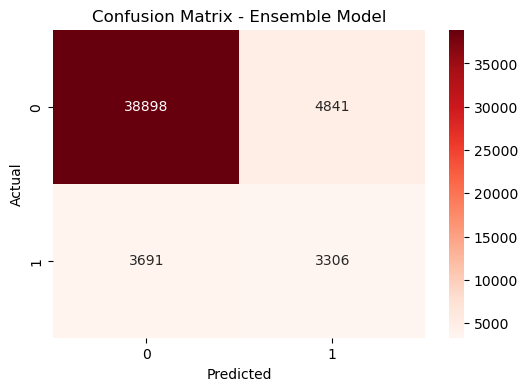

In [26]:
# ============================================================
# ENSEMBLE MODEL - SOFT VOTING CLASSIFIER
# Uses final Logistic Regression, kNN, SVM, and Decision Tree
# Shows BOTH training and test results
# ============================================================

from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    accuracy_score
)
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Final Logistic Regression
# ------------------------------------------------------------
lr_ensemble = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        C=0.1,
        penalty='l2',
        solver='lbfgs'
    ))
])

# ------------------------------------------------------------
# 2. Final kNN Model
# Based on final KNN output:
# Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
# ------------------------------------------------------------
knn_ensemble = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=3,
        metric='manhattan',
        weights='uniform'
    ))
])

# ------------------------------------------------------------
# 3. Final SVM Model
# Based on final SVM output:
# Best Parameters: {'C': 1, 'kernel': 'linear'}
# ------------------------------------------------------------
svm_ensemble = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(
        C=1,
        kernel='linear',
        probability=True,
        class_weight='balanced',
        random_state=42
    ))
])

# ------------------------------------------------------------
# 4. Final Tuned Decision Tree
# Based on tuned Decision Tree output
# ------------------------------------------------------------
dt_ensemble = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=10
)

# ------------------------------------------------------------
# Soft Voting Ensemble
# ------------------------------------------------------------
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr_ensemble),
        ('knn', knn_ensemble),
        ('svm', svm_ensemble),
        ('dt', dt_ensemble)
    ],
    voting='soft'
)

# ------------------------------------------------------------
# Train Ensemble Model
# ------------------------------------------------------------
ensemble.fit(X_train, y_train)

# ------------------------------------------------------------
# Training Predictions
# ------------------------------------------------------------
y_train_pred_ens = ensemble.predict(X_train)
y_train_prob_ens = ensemble.predict_proba(X_train)[:, 1]

print("========== ENSEMBLE MODEL ==========")

print("\n--- Training Results ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred_ens))
print("ROC-AUC:", roc_auc_score(y_train, y_train_prob_ens))
print(classification_report(y_train, y_train_pred_ens))

# ------------------------------------------------------------
# Test Predictions
# ------------------------------------------------------------
y_test_pred_ens = ensemble.predict(X_test)
y_test_prob_ens = ensemble.predict_proba(X_test)[:, 1]

print("\n--- Test Results ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred_ens))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_ens))
print(classification_report(y_test, y_test_pred_ens))

# ------------------------------------------------------------
# Confusion Matrix - Test
# ------------------------------------------------------------
cm_ensemble = confusion_matrix(y_test, y_test_pred_ens)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Reds')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ensemble Model")
plt.show()